# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 24 - 2do bimestre 2026

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 5 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/6yGAsYUywfSshnik9)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

In [30]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import r2_score
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
import random

In [76]:
seed = 7
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [32]:
train_df = pd.read_csv("adult_train.csv")
val_df = pd.read_csv("adult_val.csv")
train_df.head(10)

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K
5,37,Private,Masters,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,personal_care_assistance,United-States,<=50K
6,49,Private,9th,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,food_service_kitchen_basic,Jamaica,<=50K
7,52,Self-emp-not-inc,HS-grad,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,transport_commercial_driving,United-States,>50K
8,31,Private,Masters,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,tech_software_engineering,United-States,>50K
9,42,Private,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,consulting_process_improvement,United-States,>50K


In [3]:
print(train_df.shape)
train_df.info()

(30162, 14)
<class 'pandas.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             30162 non-null  int64
 1   workclass       30162 non-null  str  
 2   education       30162 non-null  str  
 3   marital-status  30162 non-null  str  
 4   occupation      30162 non-null  str  
 5   relationship    30162 non-null  str  
 6   race            30162 non-null  str  
 7   sex             30162 non-null  str  
 8   capital-gain    30162 non-null  int64
 9   capital-loss    30162 non-null  int64
 10  hours-per-week  30162 non-null  int64
 11  skill-profile   30162 non-null  str  
 12  native-country  30162 non-null  str  
 13  income          30162 non-null  str  
dtypes: int64(4), str(10)
memory usage: 3.2 MB


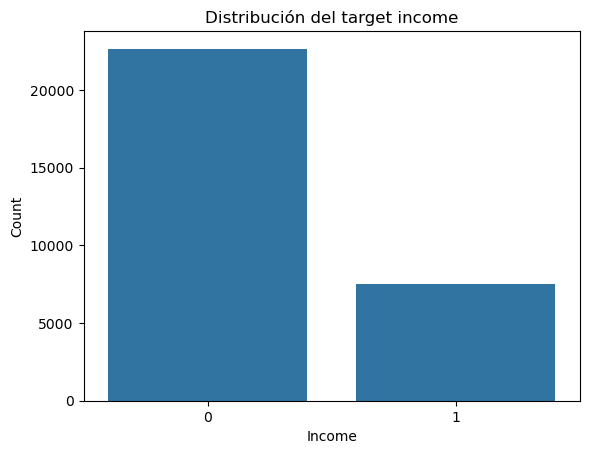

In [29]:
sns.countplot(x="income", data=train_df)
plt.title("Distribución del target income")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

Estamos ante un problema de clasificación binaria, transformo el target en una vairable binaria:

In [33]:
train_df["income"] = (train_df["income"].astype(str).str.strip().str.rstrip(".") == ">50K").astype(int)
val_df["income"] = (val_df["income"].astype(str).str.strip().str.rstrip(".") == ">50K").astype(int)

Analizo variables numericas:

In [34]:
train_df.describe()

,age,capital-gain,capital-loss,hours-per-week,income
count,30162.000000,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,1092.007858,88.372489,40.931238,0.248922
std,13.134665,7406.346497,404.298370,11.979984,0.432396
min,17.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,0.000000,0.000000,40.000000,0.000000
75%,47.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,99999.000000,4356.000000,99.000000,1.000000


In [45]:
print("Target = 1")
display(train_df[train_df["income"] == 1].drop(columns="income").describe())

print("Target = 0")
display(train_df[train_df["income"] == 0].drop(columns="income").describe())

Target = 1


,age,capital-gain,capital-loss,hours-per-week
count,7508.000000,7508.000000,7508.000000,7508.000000
mean,43.959110,3937.679808,193.750666,45.706580
std,10.269633,14386.060019,592.825590,10.736987
min,19.000000,0.000000,0.000000,1.000000
25%,36.000000,0.000000,0.000000,40.000000
50%,43.000000,0.000000,0.000000,40.000000
75%,51.000000,0.000000,0.000000,50.000000
max,90.000000,99999.000000,3683.000000,99.000000


Target = 0


,age,capital-gain,capital-loss,hours-per-week
count,22654.000000,22654.000000,22654.000000,22654.000000
mean,36.608060,148.893838,53.448000,39.348592
std,13.464631,936.392280,310.270263,11.950774
min,17.000000,0.000000,0.000000,1.000000
25%,26.000000,0.000000,0.000000,38.000000
50%,34.000000,0.000000,0.000000,40.000000
75%,45.000000,0.000000,0.000000,40.000000
max,90.000000,41310.000000,4356.000000,99.000000


Analizo variables categoricas:

Cardinalidad de workclass: 7
Value counts para workclass:
workclass
Private             22286
Self-emp-not-inc     2499
Local-gov            2067
State-gov            1279
Self-emp-inc         1074
Federal-gov           943
Without-pay            14
Name: count, dtype: int64



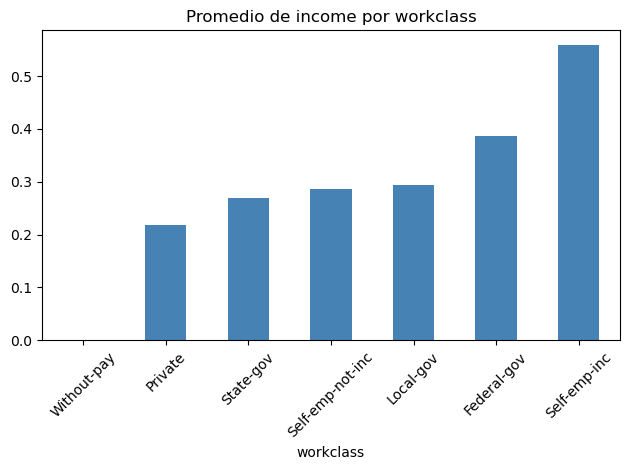

Cardinalidad de education: 16
Value counts para education:
education
HS-grad         9840
Some-college    6678
Bachelors       5044
Masters         1627
Assoc-voc       1307
11th            1048
Assoc-acdm      1008
10th             820
7th-8th          557
Prof-school      542
9th              455
12th             377
Doctorate        375
5th-6th          288
1st-4th          151
Preschool         45
Name: count, dtype: int64



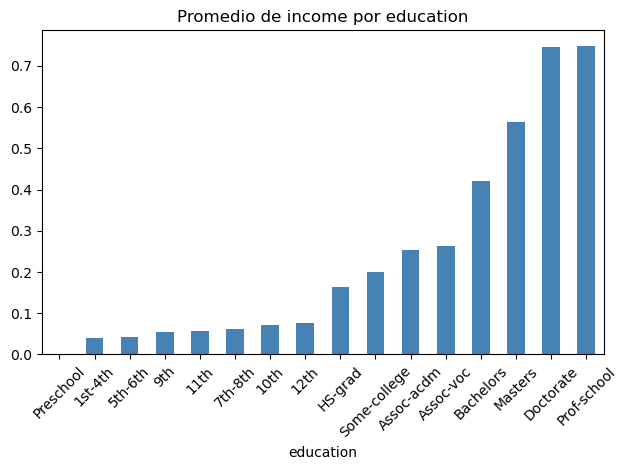

Cardinalidad de marital-status: 7
Value counts para marital-status:
marital-status
Married-civ-spouse       14065
Never-married             9726
Divorced                  4214
Separated                  939
Widowed                    827
Married-spouse-absent      370
Married-AF-spouse           21
Name: count, dtype: int64



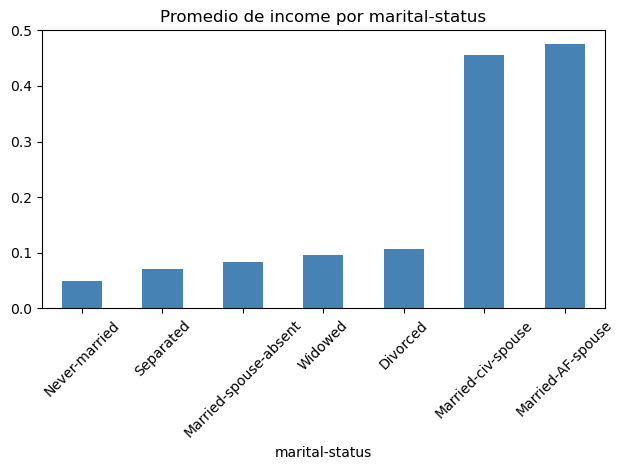

Cardinalidad de occupation: 14
Value counts para occupation:
occupation
Prof-specialty       4038
Craft-repair         4030
Exec-managerial      3992
Adm-clerical         3721
Sales                3584
Other-service        3212
Machine-op-inspct    1966
Transport-moving     1572
Handlers-cleaners    1350
Farming-fishing       989
Tech-support          912
Protective-serv       644
Priv-house-serv       143
Armed-Forces            9
Name: count, dtype: int64



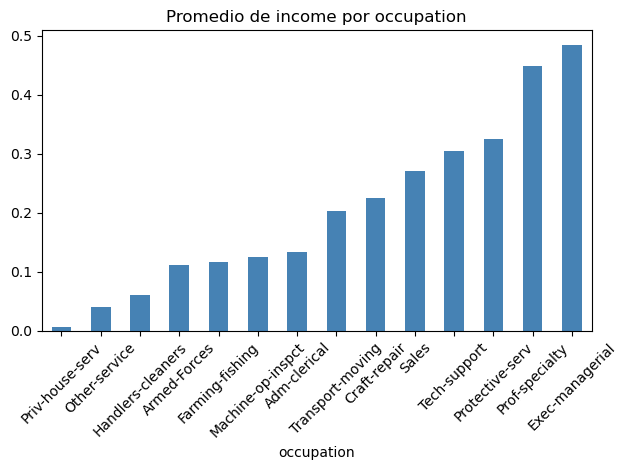

Cardinalidad de relationship: 6
Value counts para relationship:
relationship
Husband           12463
Not-in-family      7726
Own-child          4466
Unmarried          3212
Wife               1406
Other-relative      889
Name: count, dtype: int64



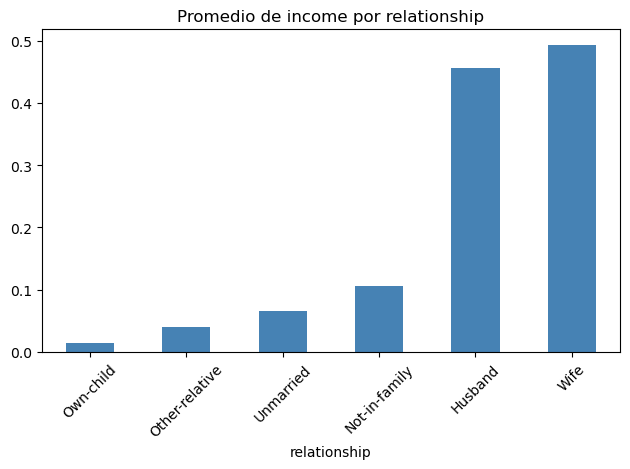

Cardinalidad de race: 5
Value counts para race:
race
White                 25933
Black                  2817
Asian-Pac-Islander      895
Amer-Indian-Eskimo      286
Other                   231
Name: count, dtype: int64



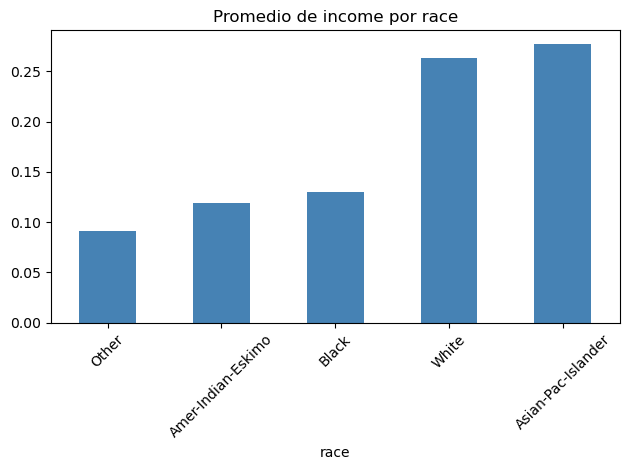

Cardinalidad de sex: 2
Value counts para sex:
sex
Male      20380
Female     9782
Name: count, dtype: int64



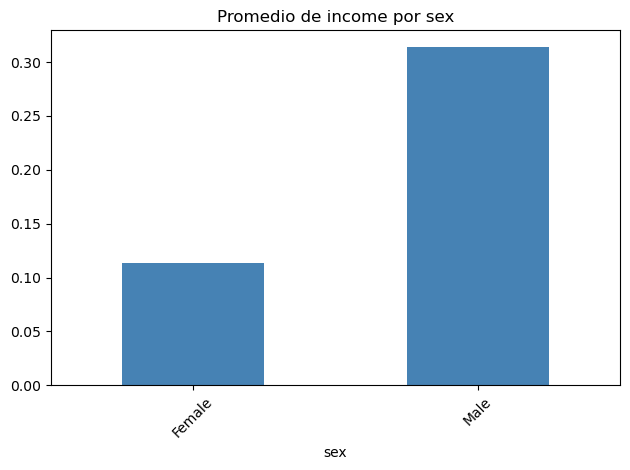

Cardinalidad de skill-profile: 80
Value counts para skill-profile:
skill-profile
customer_service_retail          2720
food_service_kitchen_basic       1668
agriculture_field_work           1638
maintenance_janitorial           1610
manufacturing_assembly           1476
                                 ... 
legal_office_support               48
education_research_methods         47
research_statistical_analysis      44
executive_decision_support         37
research_scientific_writing        26
Name: count, Length: 80, dtype: int64



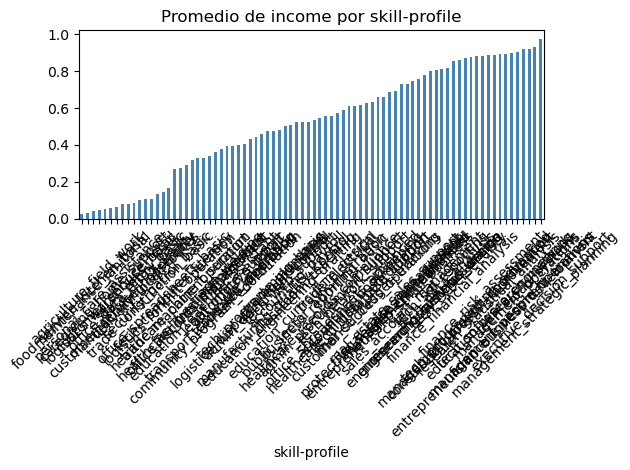

Cardinalidad de native-country: 41
Value counts para native-country:
native-country
United-States                 27504
Mexico                          610
Philippines                     188
Germany                         128
Puerto-Rico                     109
Canada                          107
India                           100
El-Salvador                     100
Cuba                             92
England                          86
Jamaica                          80
South                            71
Italy                            68
China                            68
Dominican-Republic               67
Vietnam                          64
Guatemala                        63
Japan                            59
Poland                           56
Columbia                         56
Iran                             42
Taiwan                           42
Haiti                            42
Portugal                         34
Nicaragua                        33
Peru            

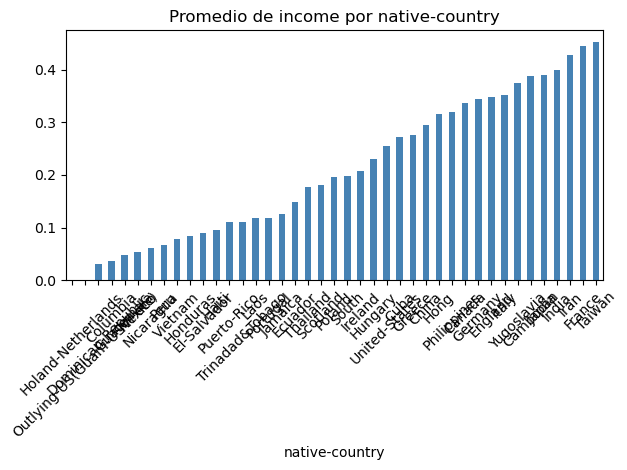

In [26]:
def plot_target_by_category(column, data=train_df, target_col="income"):
  data.groupby(column)[target_col].mean().sort_values().plot(kind="bar", color="steelblue")
  plt.title(f"Promedio de {target_col} por {column}")
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

def analyze_categorical_feature(column, data=train_df, target_col="income"):
  print(f"Cardinalidad de {column}: {data[column].nunique()}")
  print(f"Value counts para {column}:\n{data[column].value_counts()}\n")
  plot_target_by_category(column, data=data, target_col=target_col)

analyze_categorical_feature("workclass")
analyze_categorical_feature("education")
analyze_categorical_feature("marital-status")
analyze_categorical_feature("occupation")
analyze_categorical_feature("relationship")
analyze_categorical_feature("race")
analyze_categorical_feature("sex")
analyze_categorical_feature("skill-profile")
analyze_categorical_feature("native-country")

In [ ]:
# Decisions:
# - Numeric: age, capital-gain, capital-loss, hours-per-week -> StandardScaler
# - One-hot: workclass, education, marital-status, relationship, race, sex
# - Embeddings: occupation, skill-profile, native-country


numeric_cols = ["age", "capital-gain", "capital-loss", "hours-per-week"]
onehot_cols = ["workclass", "education", "marital-status", "relationship", "race", "sex"]
embed_cols = ["occupation", "skill-profile", "native-country"]
target_col = "income"

scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_df[numeric_cols]).astype(np.float32)
X_val_num = scaler.transform(val_df[numeric_cols]).astype(np.float32)

train_ohe = pd.get_dummies(pd.DataFrame({c: train_df[c].astype(str).str.strip() for c in onehot_cols}), columns=onehot_cols)
val_ohe = pd.get_dummies(pd.DataFrame({c: val_df[c].astype(str).str.strip() for c in onehot_cols}), columns=onehot_cols)
train_ohe, val_ohe = train_ohe.align(val_ohe, join="outer", axis=1, fill_value=0)
X_train_ohe = train_ohe.to_numpy(dtype=np.float32)
X_val_ohe = val_ohe.to_numpy(dtype=np.float32)


def encode_for_embedding(train_series, val_series):
  train_clean = train_series.astype(str).str.strip()
  val_clean = val_series.astype(str).str.strip()
  categories = train_clean.unique().tolist()
  mapping = {category: index + 1 for index, category in enumerate(categories)}
  train_idx = train_clean.map(mapping).fillna(0).astype(np.int64).to_numpy()
  val_idx = val_clean.map(mapping).fillna(0).astype(np.int64).to_numpy()
  return train_idx, val_idx, len(mapping) + 1


occ_train, occ_val, occ_n = encode_for_embedding(train_df["occupation"], val_df["occupation"])
skill_train, skill_val, skill_n = encode_for_embedding(train_df["skill-profile"], val_df["skill-profile"])
country_train, country_val, country_n = encode_for_embedding(train_df["native-country"], val_df["native-country"])

X_train_dense = np.concatenate([X_train_num, X_train_ohe], axis=1).astype(np.float32)
X_val_dense = np.concatenate([X_val_num, X_val_ohe], axis=1).astype(np.float32)
y_train = train_df[target_col].astype(np.float32).to_numpy().reshape(-1, 1)
y_val = val_df[target_col].astype(np.float32).to_numpy().reshape(-1, 1)

train_dataset = TensorDataset(
  torch.tensor(X_train_dense),
  torch.tensor(occ_train),
  torch.tensor(skill_train),
  torch.tensor(country_train),
  torch.tensor(y_train),
)
val_dataset = TensorDataset(
  torch.tensor(X_val_dense),
  torch.tensor(occ_val),
  torch.tensor(skill_val),
  torch.tensor(country_val),
  torch.tensor(y_val),
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.

relu: buen punto de partida. 
sigmoid: capa de salida para modelos de clasificacion binaria

Epoch 1/10 | Train Loss: 0.3496 | Train Acc: 0.8397 | Train F1: 0.7698 | Val Loss: 0.2830 | Val Acc: 0.8752 | Val F1: 0.8251
Epoch 2/10 | Train Loss: 0.2834 | Train Acc: 0.8796 | Train F1: 0.8348 | Val Loss: 0.2680 | Val Acc: 0.8865 | Val F1: 0.8402
Epoch 3/10 | Train Loss: 0.2706 | Train Acc: 0.8846 | Train F1: 0.8418 | Val Loss: 0.2617 | Val Acc: 0.8908 | Val F1: 0.8467
Epoch 4/10 | Train Loss: 0.2630 | Train Acc: 0.8883 | Train F1: 0.8469 | Val Loss: 0.2570 | Val Acc: 0.8910 | Val F1: 0.8467
Epoch 5/10 | Train Loss: 0.2602 | Train Acc: 0.8896 | Train F1: 0.8488 | Val Loss: 0.2553 | Val Acc: 0.8923 | Val F1: 0.8503
Epoch 6/10 | Train Loss: 0.2570 | Train Acc: 0.8914 | Train F1: 0.8511 | Val Loss: 0.2542 | Val Acc: 0.8926 | Val F1: 0.8491
Epoch 7/10 | Train Loss: 0.2549 | Train Acc: 0.8926 | Train F1: 0.8527 | Val Loss: 0.2532 | Val Acc: 0.8934 | Val F1: 0.8518
Epoch 8/10 | Train Loss: 0.2527 | Train Acc: 0.8938 | Train F1: 0.8545 | Val Loss: 0.2533 | Val Acc: 0.8940 | Val F1: 0.8527


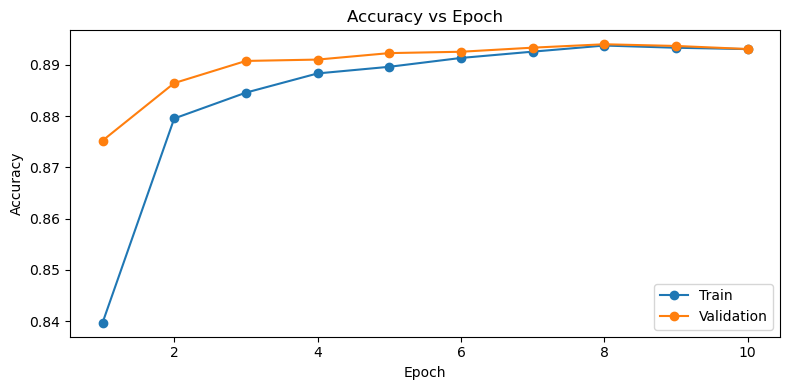

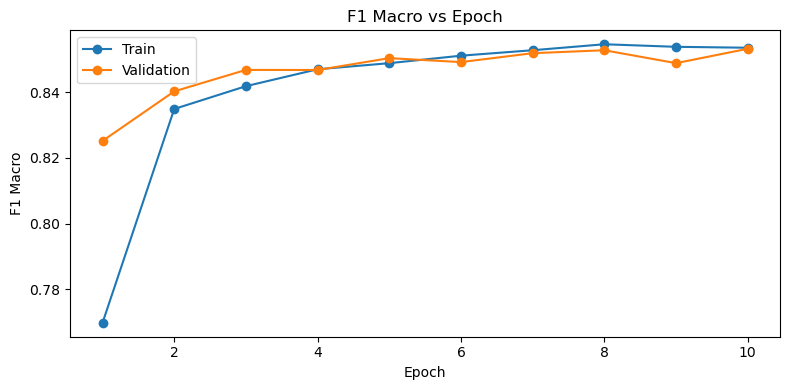

Classification report (validation):
              precision    recall  f1-score   support

           0     0.9219    0.9377    0.9297     11360
           1     0.7981    0.7562    0.7766      3700

    accuracy                         0.8931     15060
   macro avg     0.8600    0.8469    0.8532     15060
weighted avg     0.8915    0.8931    0.8921     15060



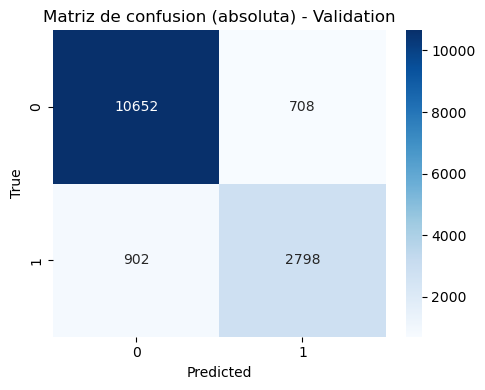

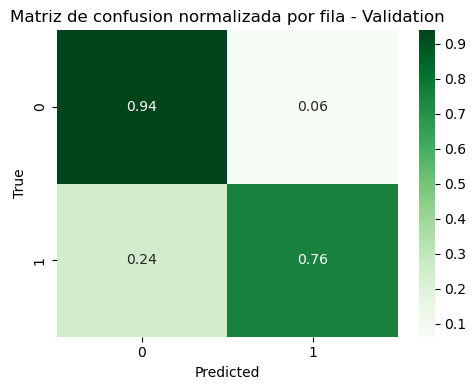

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

EPOCHS = 10
LR = 1e-3

torch.cuda.empty_cache()


class AdultIncomeModel(nn.Module):
  def __init__(self, dense_dim, occ_card, skill_card, country_card):
    super().__init__()
    self.occ_emb = nn.Embedding(occ_card, 2)
    self.skill_emb = nn.Embedding(skill_card, 4)
    self.country_emb = nn.Embedding(country_card, 2)
    self.net = nn.Sequential(
      nn.Linear(dense_dim + 2 + 4 + 2, 32),
      nn.ReLU(),
      nn.Dropout(0.2),

      nn.Linear(32, 1),
      nn.Sigmoid(),
    )

  def forward(self, dense, occ, skill, country):
    x = torch.cat(
      [dense, self.occ_emb(occ), self.skill_emb(skill), self.country_emb(country)],
      dim=1,
    )
    return self.net(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AdultIncomeModel(
  dense_dim=X_train_dense.shape[1],
  occ_card=occ_n,
  skill_card=skill_n,
  country_card=country_n,
).to(device)
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {
  "train_acc": [],
  "val_acc": [],
  "train_f1": [],
  "val_f1": [],
  "train_loss": [],
  "val_loss": [],
}

def run_epoch(loader, train=True):
  model.train() if train else model.eval()
  total_loss = 0.0
  y_true_all = []
  y_pred_all = []

  for dense, occ, skill, country, y in loader:
    dense = dense.to(device)
    occ = occ.to(device)
    skill = skill.to(device)
    country = country.to(device)
    y = y.to(device)

    if train:
      optimizer.zero_grad()

    with torch.set_grad_enabled(train):
      probs = model(dense, occ, skill, country)
      loss = loss_fn(probs, y)

      if train:
        loss.backward()
        optimizer.step()

    preds = (probs >= 0.5).float()
    total_loss += loss.item() * y.size(0)
    y_true_all.extend(y.detach().cpu().numpy().ravel().astype(int).tolist())
    y_pred_all.extend(preds.detach().cpu().numpy().ravel().astype(int).tolist())

  epoch_loss = total_loss / len(loader.dataset)
  epoch_acc = accuracy_score(y_true_all, y_pred_all)
  epoch_f1 = f1_score(y_true_all, y_pred_all, average="macro")
  return epoch_loss, epoch_acc, epoch_f1


for epoch in range(1, EPOCHS + 1):
  train_loss, train_acc, train_f1 = run_epoch(train_loader, train=True)
  val_loss, val_acc, val_f1 = run_epoch(val_loader, train=False)

  history["train_loss"].append(train_loss)
  history["val_loss"].append(val_loss)
  history["train_acc"].append(train_acc)
  history["val_acc"].append(val_acc)
  history["train_f1"].append(train_f1)
  history["val_f1"].append(val_f1)

  print(
    f"Epoch {epoch}/{EPOCHS} | "
    f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f} | "
    f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
  )

# Curva de accuracy vs epoch
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history["train_acc"], marker="o", label="Train")
plt.plot(epochs_range, history["val_acc"], marker="o", label="Validation")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Curva de F1 macro vs epoch
plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history["train_f1"], marker="o", label="Train")
plt.plot(epochs_range, history["val_f1"], marker="o", label="Validation")
plt.title("F1 Macro vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("F1 Macro")
plt.legend()
plt.tight_layout()
plt.show()

# Predicciones finales en validation
model.eval()
y_val_true = []
y_val_pred = []
with torch.no_grad():
    for dense, occ, skill, country, y in val_loader:
        dense = dense.to(device)
        occ = occ.to(device)
        skill = skill.to(device)
        country = country.to(device)
        probs = model(dense, occ, skill, country)
        preds = (probs >= 0.5).int().cpu().numpy().ravel()
        y_val_pred.extend(preds.tolist())
        y_val_true.extend(y.cpu().numpy().ravel().astype(int).tolist())

# Classification report
print("Classification report (validation):")
print(classification_report(y_val_true, y_val_pred, digits=4))

# Matriz de confusion absoluta
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusion (absoluta) - Validation")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Matriz de confusion normalizada por fila
cm_norm = confusion_matrix(y_val_true, y_val_pred, normalize="true")
plt.figure(figsize=(5, 4))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens")
plt.title("Matriz de confusion normalizada por fila - Validation")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.

[Model 3 - OneHot] Epoch 1/10 | Train Loss: 0.3170 | Train Acc: 0.8605 | Train F1: 0.7971 | Val Loss: 0.2688 | Val Acc: 0.8839 | Val F1: 0.8297
[Model 3 - OneHot] Epoch 2/10 | Train Loss: 0.2647 | Train Acc: 0.8868 | Train F1: 0.8445 | Val Loss: 0.2574 | Val Acc: 0.8912 | Val F1: 0.8484
[Model 3 - OneHot] Epoch 3/10 | Train Loss: 0.2589 | Train Acc: 0.8918 | Train F1: 0.8516 | Val Loss: 0.2552 | Val Acc: 0.8930 | Val F1: 0.8484
[Model 3 - OneHot] Epoch 4/10 | Train Loss: 0.2549 | Train Acc: 0.8934 | Train F1: 0.8537 | Val Loss: 0.2541 | Val Acc: 0.8942 | Val F1: 0.8505
[Model 3 - OneHot] Epoch 5/10 | Train Loss: 0.2518 | Train Acc: 0.8942 | Train F1: 0.8549 | Val Loss: 0.2531 | Val Acc: 0.8947 | Val F1: 0.8537
[Model 3 - OneHot] Epoch 6/10 | Train Loss: 0.2505 | Train Acc: 0.8945 | Train F1: 0.8552 | Val Loss: 0.2530 | Val Acc: 0.8942 | Val F1: 0.8520
[Model 3 - OneHot] Epoch 7/10 | Train Loss: 0.2494 | Train Acc: 0.8952 | Train F1: 0.8561 | Val Loss: 0.2525 | Val Acc: 0.8944 | Val F1:

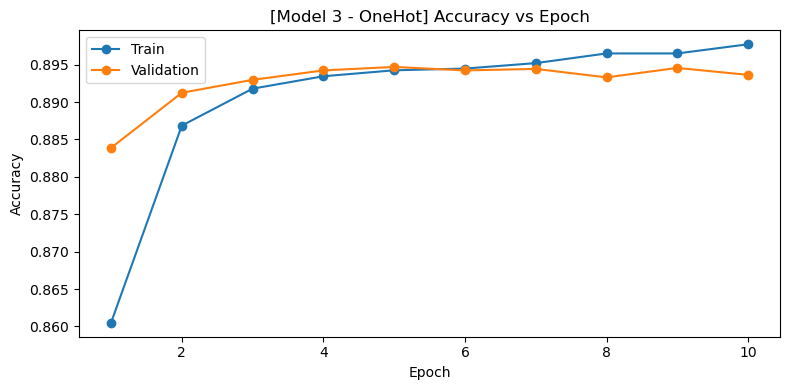

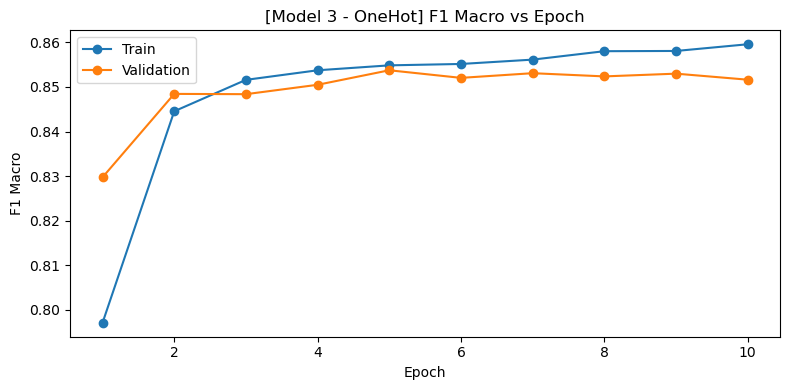

[Model 3 - OneHot] Classification report (validation):
              precision    recall  f1-score   support

           0     0.9166    0.9450    0.9306     11360
           1     0.8133    0.7359    0.7727      3700

    accuracy                         0.8936     15060
   macro avg     0.8650    0.8405    0.8516     15060
weighted avg     0.8912    0.8936    0.8918     15060



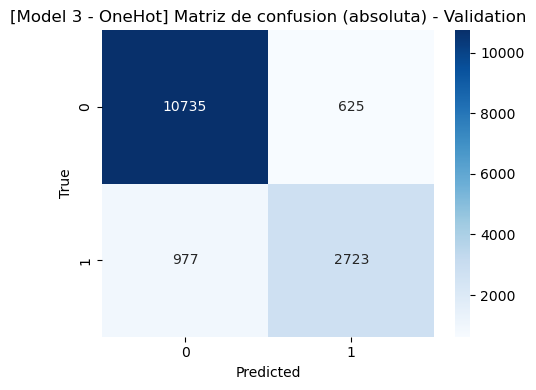

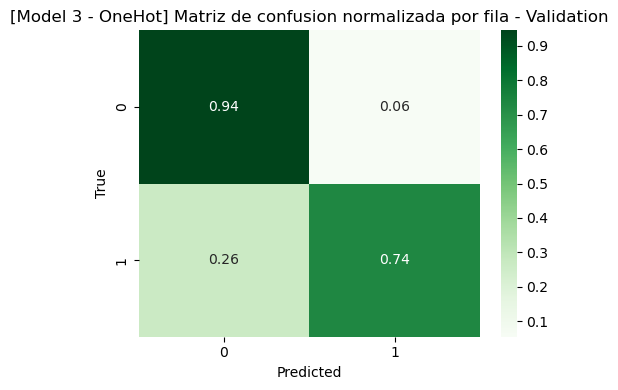

In [87]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Mismos hiperparametros del primer modelo
EPOCHS_3 = EPOCHS
LR_3 = LR

torch.cuda.empty_cache()

# Sin embeddings: one-hot para TODAS las categoricas
all_cat_cols = onehot_cols + embed_cols

train_ohe_all = pd.get_dummies(
    pd.DataFrame({c: train_df[c].astype(str).str.strip() for c in all_cat_cols}),
    columns=all_cat_cols,
)
val_ohe_all = pd.get_dummies(
    pd.DataFrame({c: val_df[c].astype(str).str.strip() for c in all_cat_cols}),
    columns=all_cat_cols,
)
train_ohe_all, val_ohe_all = train_ohe_all.align(val_ohe_all, join="outer", axis=1, fill_value=0)

X_train_all_ohe = np.concatenate([X_train_num, train_ohe_all.to_numpy(dtype=np.float32)], axis=1).astype(np.float32)
X_val_all_ohe = np.concatenate([X_val_num, val_ohe_all.to_numpy(dtype=np.float32)], axis=1).astype(np.float32)

y_train_3 = train_df[target_col].astype(np.float32).to_numpy().reshape(-1, 1)
y_val_3 = val_df[target_col].astype(np.float32).to_numpy().reshape(-1, 1)

train_dataset_3 = TensorDataset(torch.tensor(X_train_all_ohe), torch.tensor(y_train_3))
val_dataset_3 = TensorDataset(torch.tensor(X_val_all_ohe), torch.tensor(y_val_3))

train_loader_3 = DataLoader(train_dataset_3, batch_size=32, shuffle=True)
val_loader_3 = DataLoader(val_dataset_3, batch_size=32, shuffle=False)


class AdultIncomeModelNoEmb(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_3 = AdultIncomeModelNoEmb(input_dim=X_train_all_ohe.shape[1]).to(device)
loss_fn_3 = nn.BCELoss()
optimizer_3 = torch.optim.Adam(model_3.parameters(), lr=LR_3)

history_3 = {
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": [],
    "train_loss": [],
    "val_loss": [],
}


def run_epoch_3(loader, train=True):
    model_3.train() if train else model_3.eval()
    total_loss = 0.0
    y_true_all = []
    y_pred_all = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        if train:
            optimizer_3.zero_grad()

        with torch.set_grad_enabled(train):
            probs = model_3(x)
            loss = loss_fn_3(probs, y)

            if train:
                loss.backward()
                optimizer_3.step()

        preds = (probs >= 0.5).float()
        total_loss += loss.item() * y.size(0)
        y_true_all.extend(y.detach().cpu().numpy().ravel().astype(int).tolist())
        y_pred_all.extend(preds.detach().cpu().numpy().ravel().astype(int).tolist())

    epoch_loss = total_loss / len(loader.dataset)
    epoch_acc = accuracy_score(y_true_all, y_pred_all)
    epoch_f1 = f1_score(y_true_all, y_pred_all, average="macro")
    return epoch_loss, epoch_acc, epoch_f1


for epoch in range(1, EPOCHS_3 + 1):
    train_loss, train_acc, train_f1 = run_epoch_3(train_loader_3, train=True)
    val_loss, val_acc, val_f1 = run_epoch_3(val_loader_3, train=False)

    history_3["train_loss"].append(train_loss)
    history_3["val_loss"].append(val_loss)
    history_3["train_acc"].append(train_acc)
    history_3["val_acc"].append(val_acc)
    history_3["train_f1"].append(train_f1)
    history_3["val_f1"].append(val_f1)

    print(
        f"[Model 3 - OneHot] Epoch {epoch}/{EPOCHS_3} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
    )

# Curva de accuracy vs epoch
epochs_range = range(1, EPOCHS_3 + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history_3["train_acc"], marker="o", label="Train")
plt.plot(epochs_range, history_3["val_acc"], marker="o", label="Validation")
plt.title("[Model 3 - OneHot] Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Curva de F1 macro vs epoch
plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history_3["train_f1"], marker="o", label="Train")
plt.plot(epochs_range, history_3["val_f1"], marker="o", label="Validation")
plt.title("[Model 3 - OneHot] F1 Macro vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("F1 Macro")
plt.legend()
plt.tight_layout()
plt.show()

# Predicciones finales en validation
model_3.eval()
y_val_true_3 = []
y_val_pred_3 = []
with torch.no_grad():
    for x, y in val_loader_3:
        x = x.to(device)
        probs = model_3(x)
        preds = (probs >= 0.5).int().cpu().numpy().ravel()
        y_val_pred_3.extend(preds.tolist())
        y_val_true_3.extend(y.numpy().ravel().astype(int).tolist())

# Classification report
print("[Model 3 - OneHot] Classification report (validation):")
print(classification_report(y_val_true_3, y_val_pred_3, digits=4))

# Matriz de confusion absoluta
cm_3 = confusion_matrix(y_val_true_3, y_val_pred_3)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_3, annot=True, fmt="d", cmap="Blues")
plt.title("[Model 3 - OneHot] Matriz de confusion (absoluta) - Validation")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Matriz de confusion normalizada por fila
cm_norm_3 = confusion_matrix(y_val_true_3, y_val_pred_3, normalize="true")
plt.figure(figsize=(5, 4))
sns.heatmap(cm_norm_3, annot=True, fmt=".2f", cmap="Greens")
plt.title("[Model 3 - OneHot] Matriz de confusion normalizada por fila - Validation")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.